In [1]:
import sys
sys.path.insert(0, "..")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.models.node_pyomo_base import NODEPyomo

## 1. Load simulated bioreactor dataset

Loads "../datasets/bioreactor_simulation/noise_level_01_eps0.01.csv" which contains 50 time series, measurement noise σ = 0.01.  
  
Dimensions of state variable:
- Glucose (G): primary carbon/energy source consumed by cells. 
- Dissolved Oxygen (O): oxygen available for cell metabolism. 
- Viable Cells (X): live, actively growing cell concentration. 
- Dead Cells (Xd): non-viable cell concentration. 
- Product (P): target bioproduct being produced. 
- Lactate (L): metabolic byproduct of glucose consumption. 
- CO2: dissolved carbon dioxide, a metabolic waste product. 

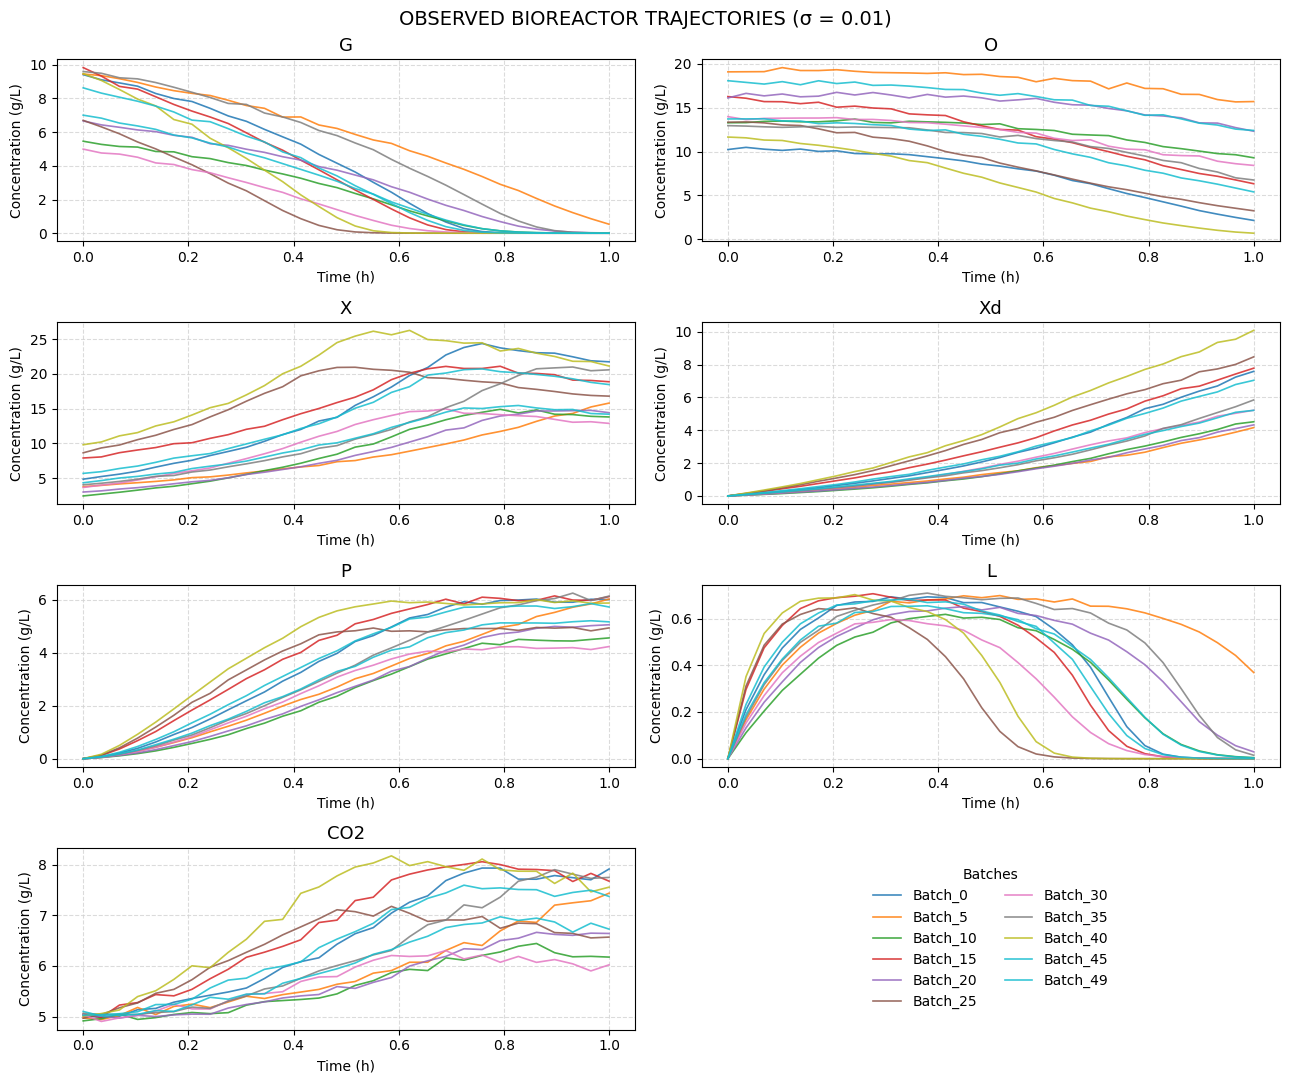

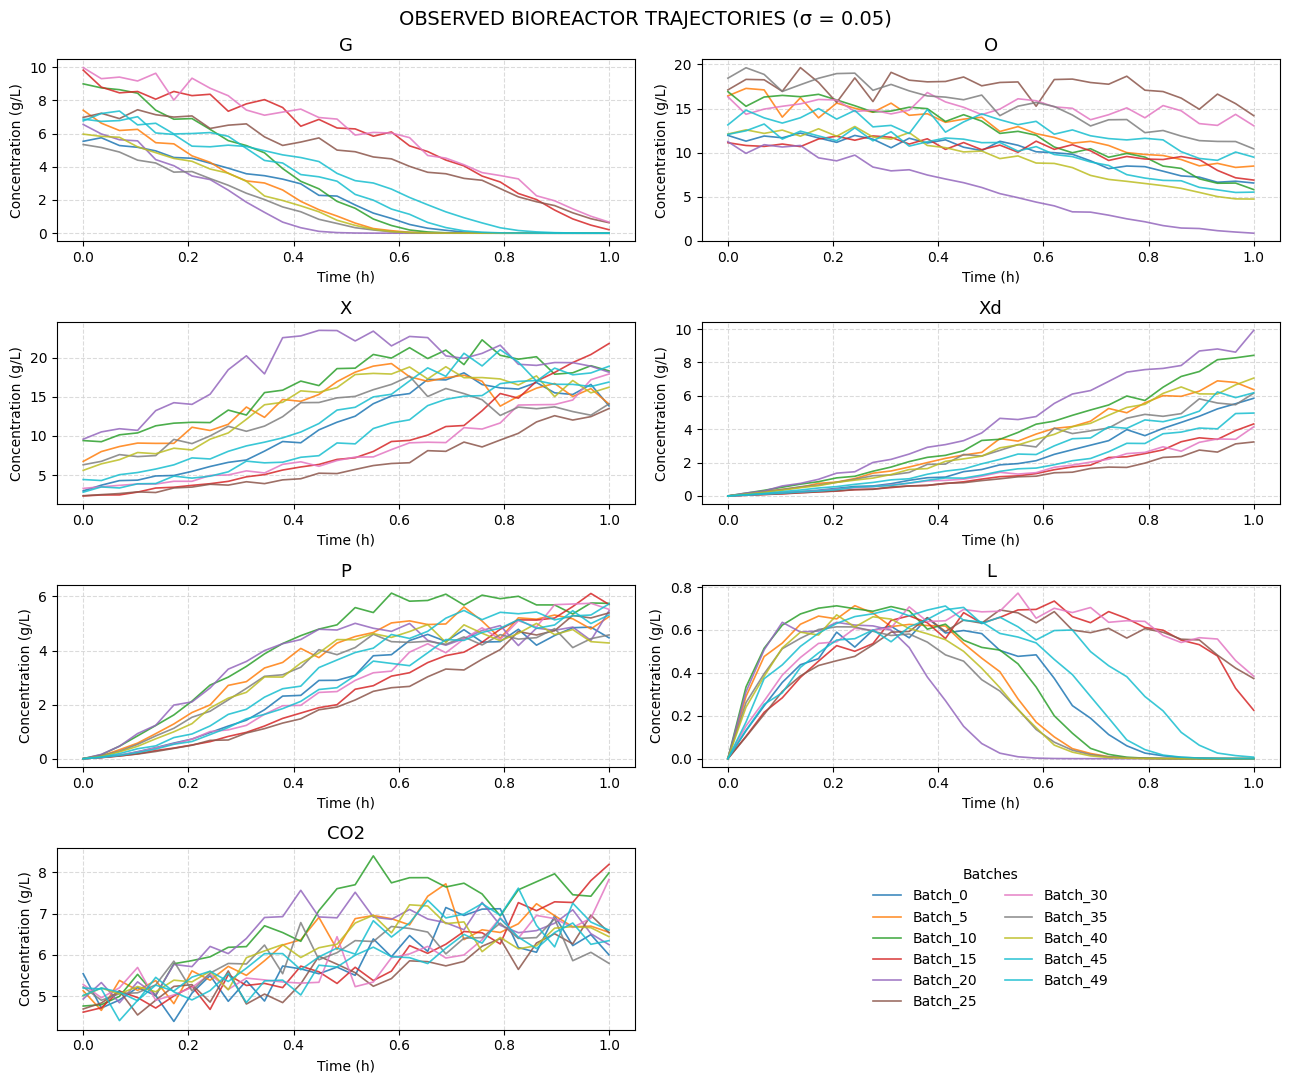

In [ ]:
STATE_COLS = ['G', 'O', 'X', 'Xd', 'P', 'L', 'CO2']
STATE_DIM = len(STATE_COLS)
TRAIN_BATCH_IDS = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 49]


# σ = 0.01 noise trajectories
LN_DATA_PATH = "../data/bioreactor_simulation/noise_level_01_eps0.01.csv"
ln_df = pd.read_csv(LN_DATA_PATH)
ln_train_batches = {
    batch_id: ln_df[ln_df['Batch'] == f"Batch_{batch_id}"].reset_index(drop=True)
    for batch_id in TRAIN_BATCH_IDS
}
ln_train_grid = ln_train_batches[TRAIN_BATCH_IDS[0]]['Time'].values

ln_fig, ln_axes = plt.subplots(4, 2, figsize=(13, 11))
ln_axes = ln_axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, len(TRAIN_BATCH_IDS)))

for i, col in enumerate(STATE_COLS):
    ax = ln_axes[i]
    for c, batch_id in zip(colors, TRAIN_BATCH_IDS):
        obs = ln_train_batches[batch_id][STATE_COLS].values
        ax.plot(
            ln_train_grid, obs[:, i],
            color=c, linewidth=1.2, alpha=0.85,
            label=f"Batch_{batch_id}"
        )
    ax.set_title(col, fontsize=13)
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('Concentration (g/L)')
    ax.grid(True, linestyle='--', color='lightgrey', alpha=0.8)

ln_handles, ln_labels = ln_axes[0].get_legend_handles_labels()
ln_axes[7].axis('off')
ln_axes[7].legend(
    ln_handles, ln_labels,
    fontsize=10, loc='center', frameon=False,
    ncol=2, title='Batches'
 )
plt.suptitle("OBSERVED BIOREACTOR TRAJECTORIES (σ = 0.01)", fontsize=14)
plt.tight_layout()


# σ = 0.05 noise trajectories
HN_DATA_PATH = "../data/bioreactor_simulation/noise_level_05_eps0.05.csv"
hn_df = pd.read_csv(HN_DATA_PATH)
hn_train_batches = {
    batch_id: hn_df[hn_df['Batch'] == f"Batch_{batch_id}"].reset_index(drop=True)
    for batch_id in TRAIN_BATCH_IDS
}
hn_train_grid = hn_train_batches[TRAIN_BATCH_IDS[0]]['Time'].values

hn_fig, hn_axes = plt.subplots(4, 2, figsize=(13, 11))
hn_axes = hn_axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, len(TRAIN_BATCH_IDS)))

for i, col in enumerate(STATE_COLS):
    ax = hn_axes[i]
    for c, batch_id in zip(colors, TRAIN_BATCH_IDS):
        obs = hn_train_batches[batch_id][STATE_COLS].values
        ax.plot(
            hn_train_grid, obs[:, i],
            color=c, linewidth=1.2, alpha=0.85,
            label=f"Batch_{batch_id}"
        )
    ax.set_title(col, fontsize=13)
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('Concentration (g/L)')
    ax.grid(True, linestyle='--', color='lightgrey', alpha=0.8)

hn_handles, hn_labels = hn_axes[0].get_legend_handles_labels()
hn_axes[7].axis('off')
hn_axes[7].legend(
    hn_handles, hn_labels,
    fontsize=10, loc='center', frameon=False,
    ncol=2, title='Batches'
 )
plt.suptitle("OBSERVED BIOREACTOR TRAJECTORIES (σ = 0.05)", fontsize=14)
plt.tight_layout()

## 2. Train Neural ODE model using IPOPT (σ = 0.01, use ma27)

In [3]:
CURRENT_BATCH_ID = 15
ln_Y_obs = ln_train_batches[CURRENT_BATCH_ID][STATE_COLS].values
ln_y0 = ln_Y_obs[0, :]
ln_dt = float(ln_train_grid[1] - ln_train_grid[0])
ln_end_time = ln_train_grid[-1]

### DC method sweeped over different NN sizes 

In [4]:
dc_hidden_widths = [4, 8, 16]
dc_nn_configs = (
    [[STATE_DIM, w, STATE_DIM] for w in dc_hidden_widths]
)
    #+ [[STATE_DIM, w, w, STATE_DIM] for w in dc_hidden_widths[:-2]]
dc_labels = [
    f"{len(cfg[1:-1])}H-{'x'.join(str(h) for h in cfg[1:-1])}"
    for cfg in dc_nn_configs
]
dc_sweep_results = {} 

solver_options_dc = {
    "max_iter": 500,
    "nlp_scaling_method": "gradient-based",
    "mu_strategy": "adaptive",
    "tol": 1e-6,
    "acceptable_tol": 1e-5,
    "acceptable_iter": 10
}

for label, nn_config in zip(dc_labels, dc_nn_configs):
    t0 = time.perf_counter()
    model = NODEPyomo(
        ln_Y_obs, nn_config, ln_end_time,
        state_lower_bound=-5,
        state_upper_bound=50,
        param_lower_bound=-100,
        param_upper_bound=100,
        lambda_reg=1e-4,
        transcription_method='dc',
    )
    model.solve_model(solver_options_dc)
    solve_time = time.perf_counter() - t0
    solve_info = getattr(model, 'last_solve_info', {})
    iterations = solve_info.get('iterations')

    try:
        predicted = model.get_predicted_trajectory(
            ln_y0, ln_train_grid, rtol=1e-7, atol=1e-9, max_step=ln_dt
        )
        status = 'ok'
    except Exception as e:
        predicted = None
        status = f'integration failed: {e}'

    dc_sweep_results[label] = {
        'layer_sizes': nn_config,
        'model': model,
        'predicted': predicted,
        'solve_time': solve_time,
        'iterations': iterations,
        'solver_status': solve_info.get('status'),
        'termination_condition': solve_info.get('termination_condition'),
        'status': status,
    }
    print(f"Solve time: {solve_time:.1f}s | Iterations: {iterations} | Integration: {status}")

dc_num_success = sum(1 for r in dc_sweep_results.values() if r['predicted'] is not None)
print(f"\nSweep complete. {dc_num_success}/{len(dc_nn_configs)} architectures integrated successfully.")

Solver available?: True
Ipopt 3.14.20: max_iter=500
nlp_scaling_method=gradient-based
mu_strategy=adaptive
print_level=5
tol=1e-06
acceptable_tol=1e-05
acceptable_iter=10
option_file_name=/Users/bms125/Desktop/Projects/PhD/CNODE/ipopt.opt

Using option file "/Users/bms125/Desktop/Projects/PhD/CNODE/ipopt.opt".


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.20, running with linear solver ma27.

Number of nonzeros in equality constraint Jacobian...:    14826
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:    13402

Total number of variables.................

### IRR-DC method sweeped over NN sizes

In [5]:
irrdc_hidden_widths = [4, 8, 16]
irrdc_nn_configs = (
    [[STATE_DIM, w, STATE_DIM] for w in dc_hidden_widths]
)
    #+ [[STATE_DIM, w, w, STATE_DIM] for w in dc_hidden_widths[:-1]]
irrdc_labels = [
    f"{len(cfg[1:-1])}H-{'x'.join(str(h) for h in cfg[1:-1])}"
    for cfg in irrdc_nn_configs
]
irrdc_sweep_results = {}

solver_options_irrdc = {
    "max_iter": 1000,
    "nlp_scaling_method": "gradient-based",
    "mu_strategy": "adaptive",
    "tol": 1e-6,
    "acceptable_tol": 1e-5,
    "acceptable_iter": 10
}

for label, nn_config in zip(irrdc_labels, irrdc_nn_configs):
    t0 = time.perf_counter()
    model = NODEPyomo(
        ln_Y_obs, nn_config, ln_end_time,
        state_lower_bound=-5,
        state_upper_bound=50,
        param_lower_bound=-100,
        param_upper_bound=100,
        lambda_reg=1e-4,
        transcription_method='irrdc',
        rho_reg=1,
        num_res_eval_nodes=50
    )
    model.solve_model(solver_options_irrdc)
    solve_time = time.perf_counter() - t0
    solve_info = getattr(model, 'last_solve_info', {})
    iterations = solve_info.get('iterations')

    try:
        predicted = model.get_predicted_trajectory(
            ln_y0, ln_train_grid, rtol=1e-7, atol=1e-9, max_step=ln_dt
        )
        status = 'ok'
    except Exception as e:
        predicted = None
        status = f'integration failed: {e}'

    irrdc_sweep_results[label] = {
        'layer_sizes': nn_config,
        'model': model,
        'predicted': predicted,
        'solve_time': solve_time,
        'iterations': iterations,
        'solver_status': solve_info.get('status'),
        'termination_condition': solve_info.get('termination_condition'),
        'status': status,
    }
    print(f"Solve time: {solve_time:.1f}s | Iterations: {iterations} | Integration: {status}")

irrdc_num_success = sum(1 for r in irrdc_sweep_results.values() if r['predicted'] is not None)
print(f"\nSweep complete. {irrdc_num_success}/{len(irrdc_nn_configs)} architectures integrated successfully.")

Number of node clashes between res eval grid and colloc grid: 2 of 50 res eval nodes.
Solver available?: True
Ipopt 3.14.20: max_iter=1000
nlp_scaling_method=gradient-based
mu_strategy=adaptive
print_level=5
tol=1e-06
acceptable_tol=1e-05
acceptable_iter=10
option_file_name=/Users/bms125/Desktop/Projects/PhD/CNODE/ipopt.opt

Using option file "/Users/bms125/Desktop/Projects/PhD/CNODE/ipopt.opt".


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.20, running with linear solver ma27.

Number of nonzeros in equality constraint Jacobian...:    14826
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros i

### Training summary table

In [6]:
rows = []

for _, res in dc_sweep_results.items():
    rows.append({
        'method': 'DC',
        'layer_sizes': res.get('layer_sizes'),
        'solve_time_s': res.get('solve_time'),
    })

for _, res in irrdc_sweep_results.items():
    rows.append({
        'method': 'IRR-DC',
        'layer_sizes': res.get('layer_sizes'),
        'solve_time_s': res.get('solve_time'),
    })

runtime_df = pd.DataFrame(
    rows,
    columns=['method', 'layer_sizes', 'solve_time_s']
 )

if not runtime_df.empty:
    # Approximate model size by total trainable parameters for the given architecture.
    def count_params(layer_sizes):
        if not isinstance(layer_sizes, (list, tuple)) or len(layer_sizes) < 2:
            return float('inf')
        return sum(
            layer_sizes[i] * layer_sizes[i + 1] + layer_sizes[i + 1]
            for i in range(len(layer_sizes) - 1)
        )

    runtime_df['model_size'] = runtime_df['layer_sizes'].map(count_params)
    runtime_df['layer_sizes_str'] = runtime_df['layer_sizes'].map(
        lambda x: str(x) if isinstance(x, (list, tuple)) else 'n/a'
    )

    method_order = {'DC': 0, 'IRR-DC': 1}
    runtime_df['method_order'] = runtime_df['method'].map(lambda m: method_order.get(m, 99))

    runtime_df = runtime_df.sort_values(
        ['model_size', 'layer_sizes_str', 'method_order']
    ).reset_index(drop=True)

    runtime_df['solve_time_s'] = runtime_df['solve_time_s'].map(
        lambda x: f"{float(x):.2f}" if pd.notnull(x) else 'n/a'
    )

    runtime_df = runtime_df[
        ['method', 'layer_sizes_str', 'solve_time_s']
    ]
    runtime_df = runtime_df.rename(columns={'layer_sizes_str': 'layer_sizes'})

display(runtime_df)

,method,layer_sizes,solve_time_s
0,DC,"[7, 4, 7]",3.23
1,IRR-DC,"[7, 4, 7]",35.79
2,DC,"[7, 8, 7]",4.78
3,IRR-DC,"[7, 8, 7]",162.84
4,DC,"[7, 16, 7]",23.74
5,IRR-DC,"[7, 16, 7]",597.86


## 3. Forward-integrate the trained models over train data and test data

In [12]:
TEST_BATCH_IDS = [8, 38]

test_batches = {
    batch_id: ln_df[ln_df['Batch'] == f"Batch_{batch_id}"].reset_index(drop=True)
    for batch_id in TEST_BATCH_IDS
}
test_grid = test_batches[TEST_BATCH_IDS[0]]['Time'].values
Y_test_obs = np.array(
    [test_batches[batch_id][STATE_COLS].values for batch_id in TEST_BATCH_IDS]
 )

predicted_train_dc = {}
predicted_test_dc = {}
for label, res in dc_sweep_results.items():
    model = res['model']
    predicted_train_dc[label] = model.get_predicted_trajectory(
        ln_y0, ln_train_grid, rtol=1e-7, atol=1e-9, max_step=ln_dt
    )
    predicted_test_dc[label] = {}
    for batch_id in TEST_BATCH_IDS:
        batch_idx = TEST_BATCH_IDS.index(batch_id)
        y0_test = Y_test_obs[batch_idx, 0, :]
        predicted_test_dc[label][batch_id] = model.get_predicted_trajectory(
            y0_test, test_grid, rtol=1e-7, atol=1e-9, max_step=ln_dt
        )

predicted_train_irrdc = {}
predicted_test_irrdc = {}
for label, res in irrdc_sweep_results.items():
    model = res['model']
    predicted_train_irrdc[label] = model.get_predicted_trajectory(
        ln_y0, ln_train_grid, rtol=1e-7, atol=1e-9, max_step=ln_dt
    )
    predicted_test_irrdc[label] = {}
    for batch_id in TEST_BATCH_IDS:
        batch_idx = TEST_BATCH_IDS.index(batch_id)
        y0_test = Y_test_obs[batch_idx, 0, :]
        predicted_test_irrdc[label][batch_id] = model.get_predicted_trajectory(
            y0_test, test_grid, rtol=1e-7, atol=1e-9, max_step=ln_dt
        )

print(f"DC train preds: {len(predicted_train_dc)} models")
print(f"IRR-DC train preds: {len(predicted_train_irrdc)} models")
print(f"Test batches: {TEST_BATCH_IDS}")

DC train preds: 3 models
IRR-DC train preds: 3 models
Test batches: [8, 38]


## 4. Plot predicted vs observed trajectories

Common layer sizes in DC and IRR-DC sweeps: ['1H-4', '1H-8', '1H-16']
DC-only layer sizes: []


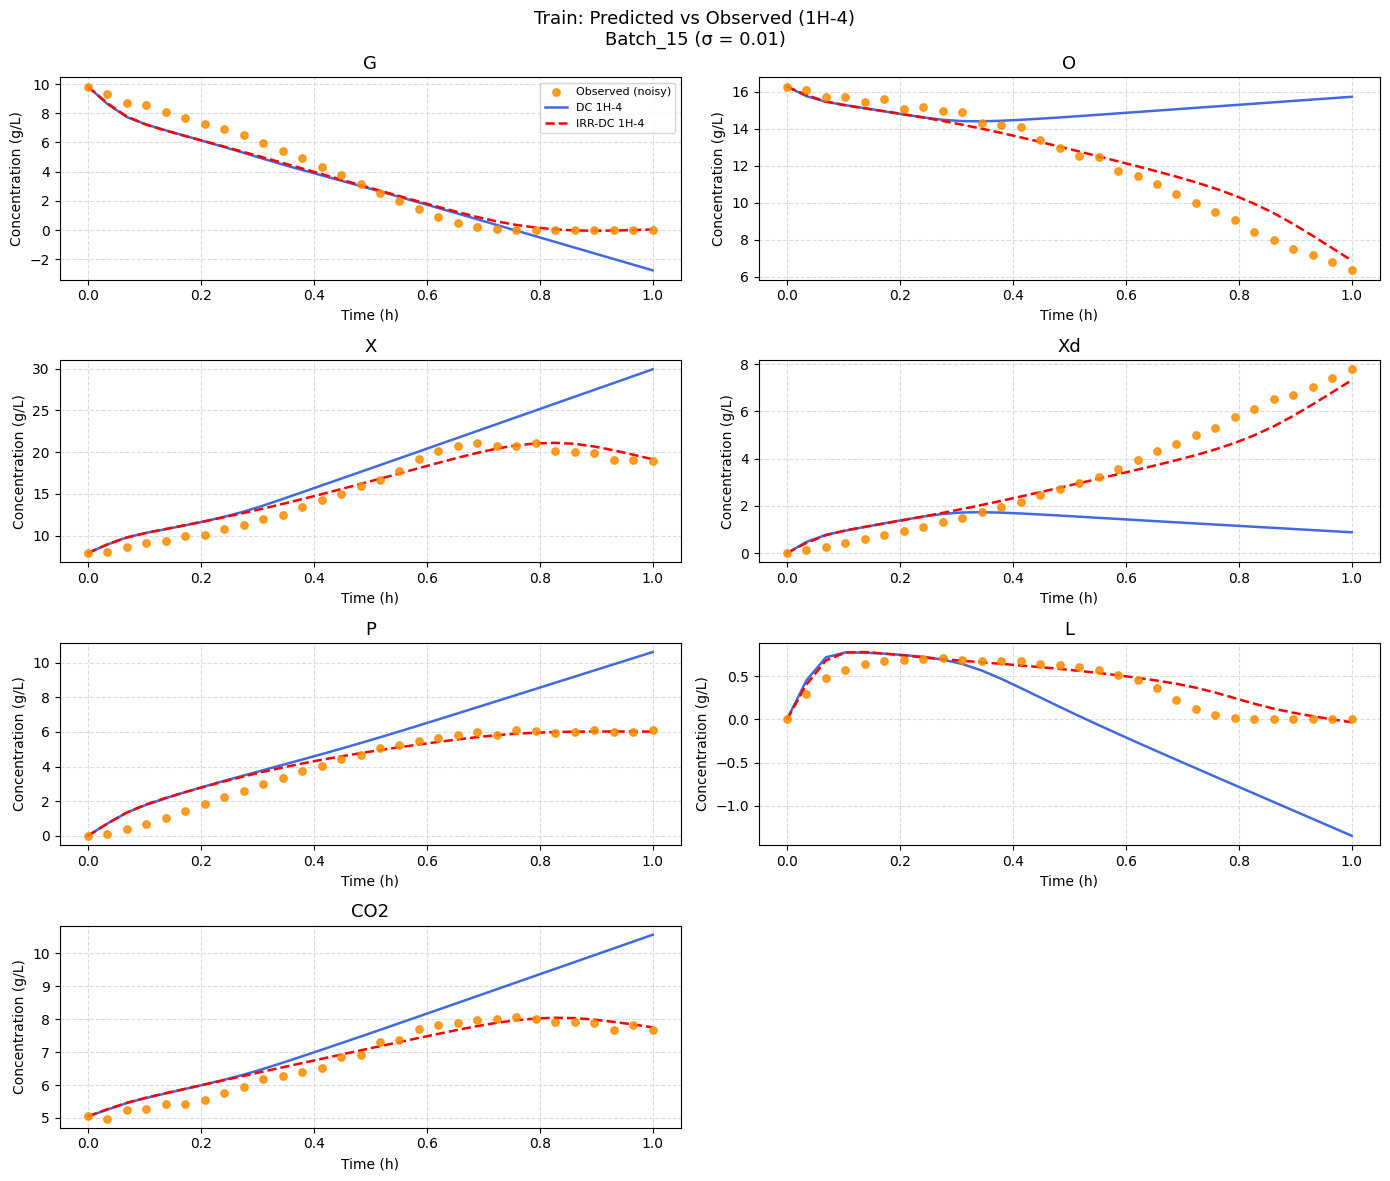

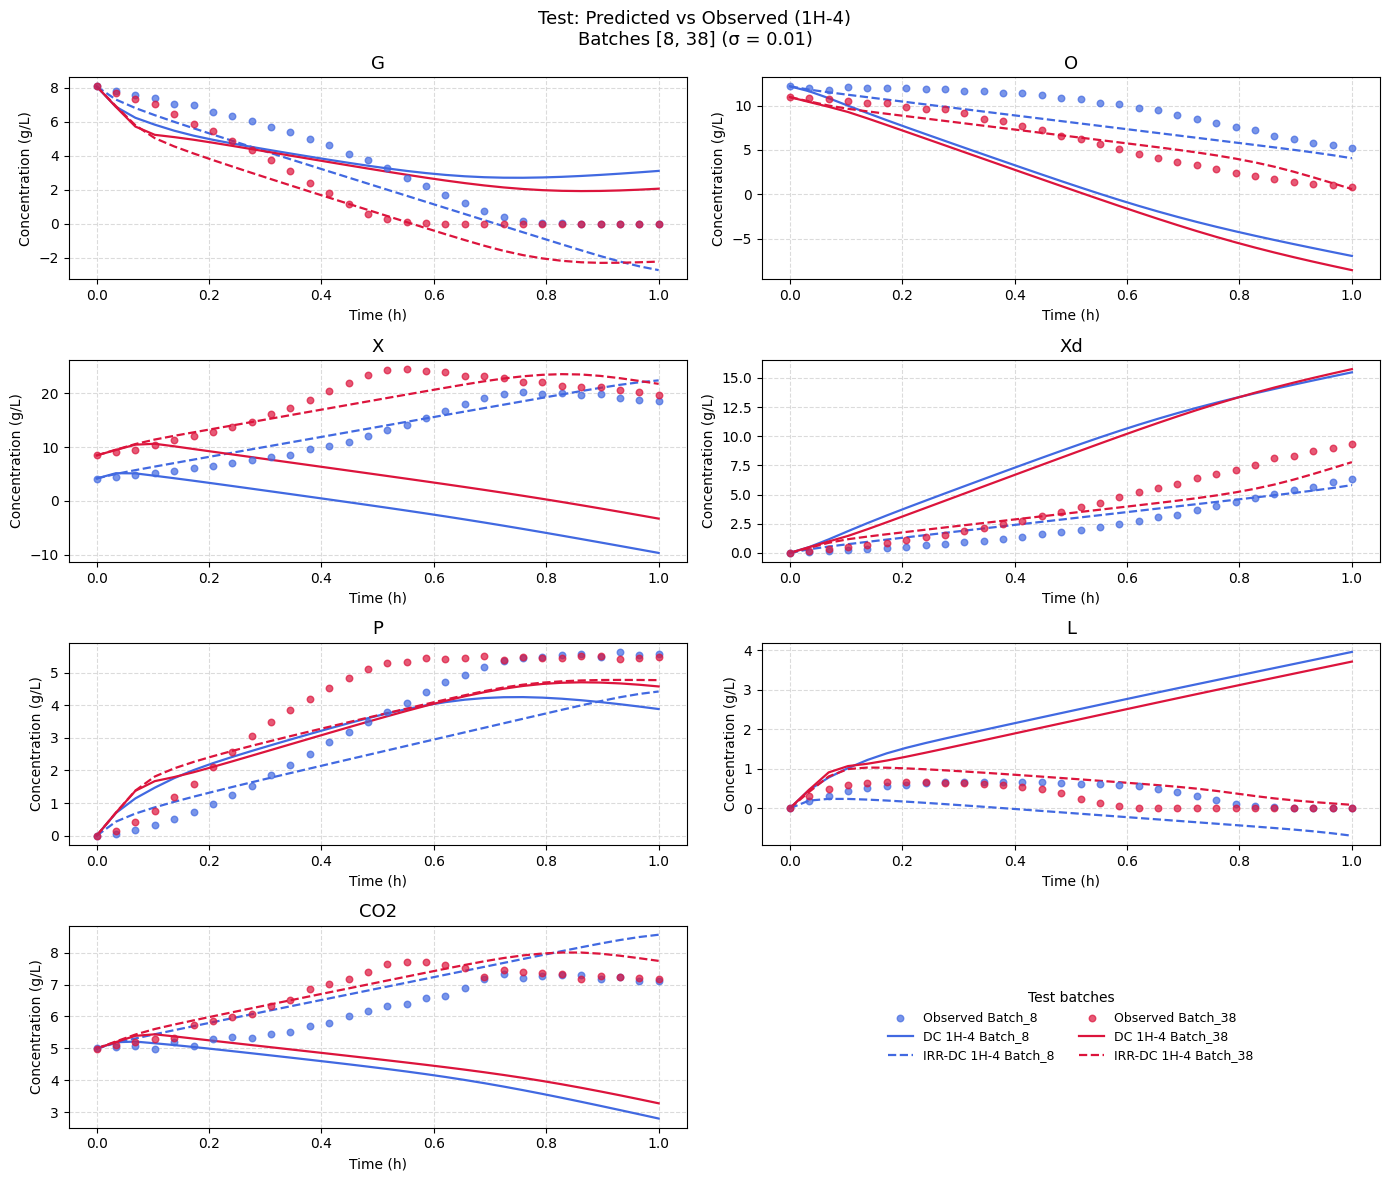

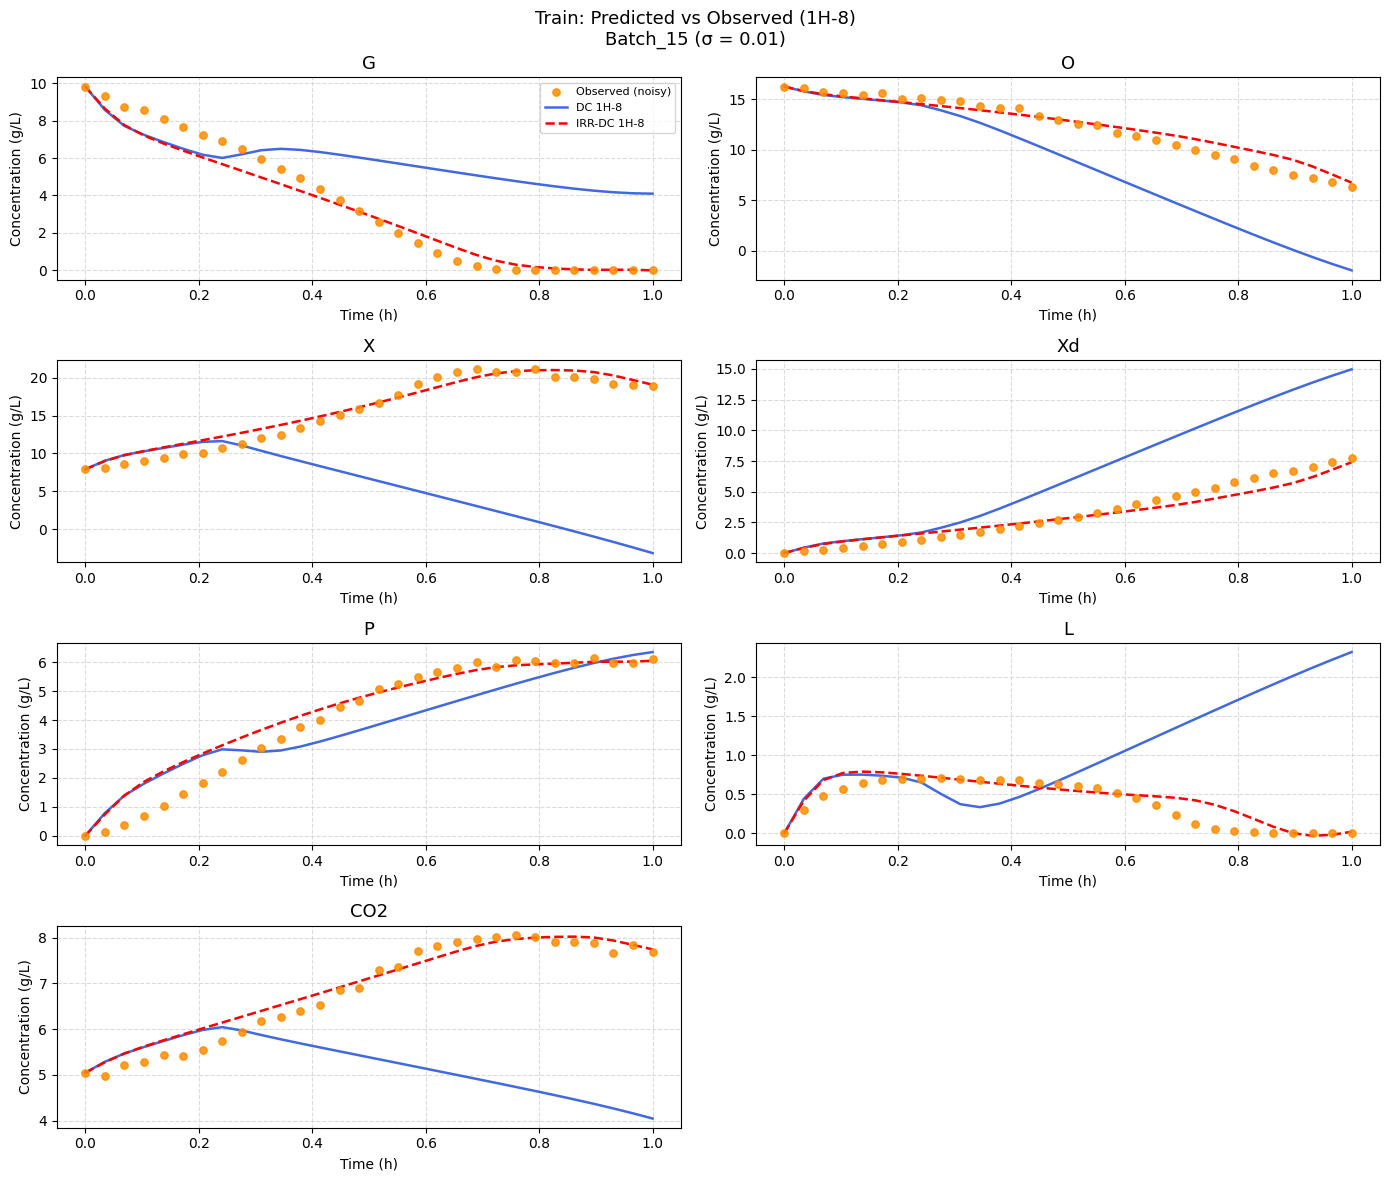

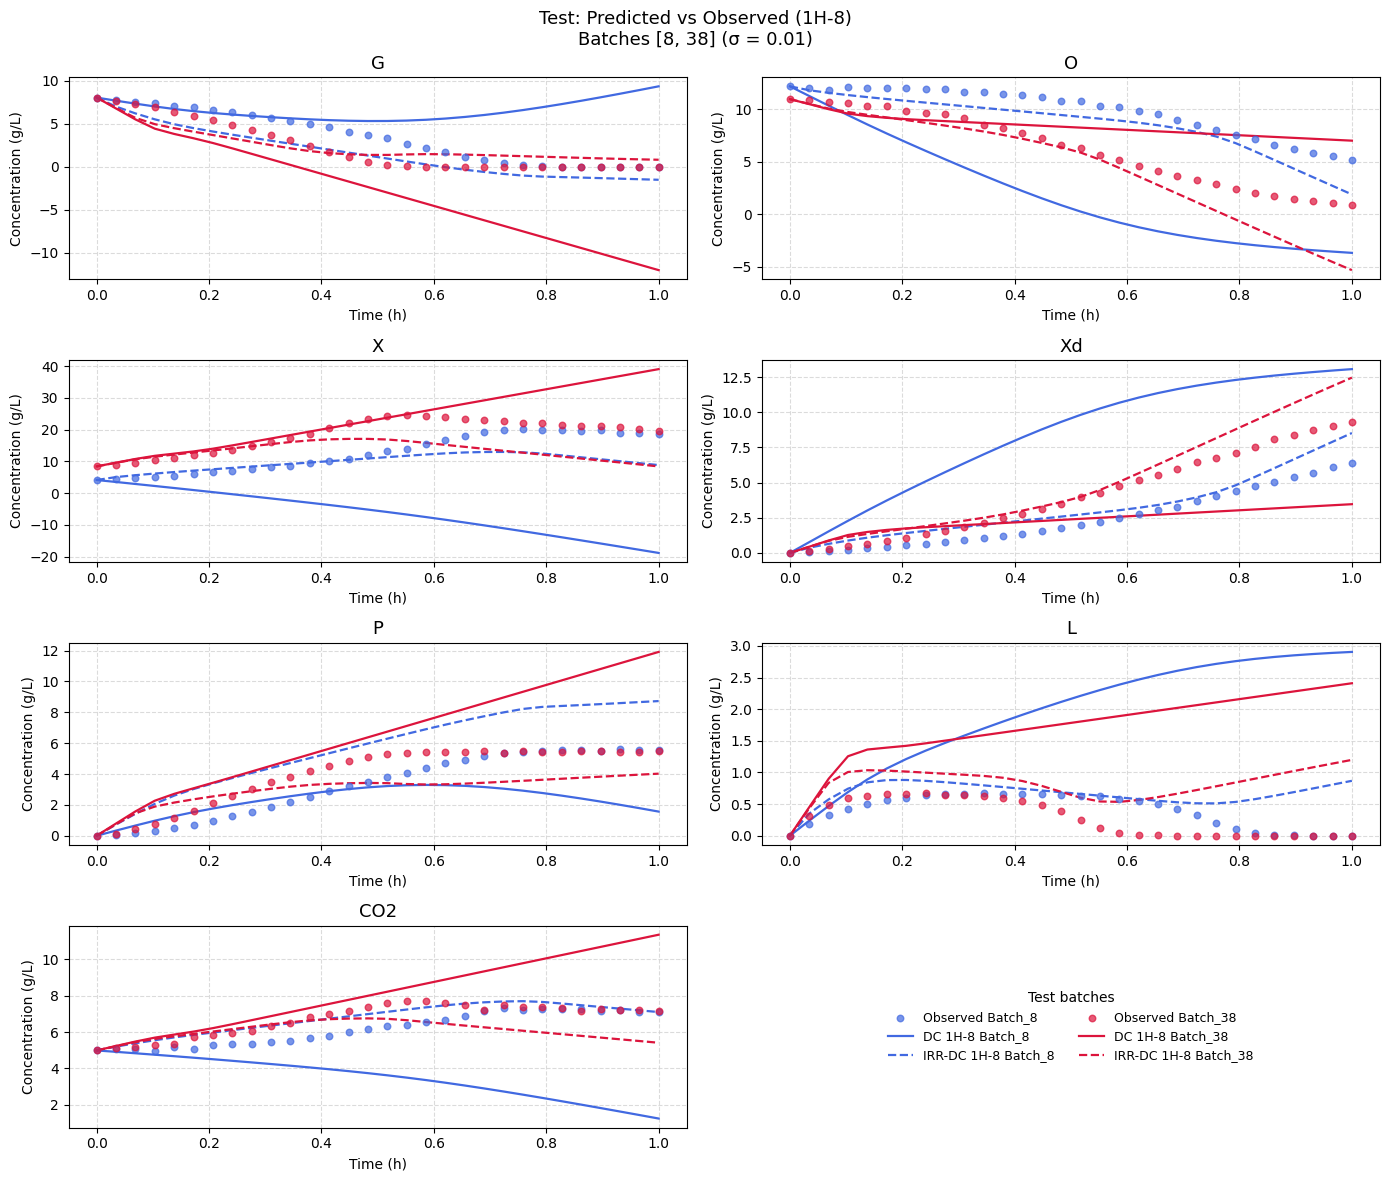

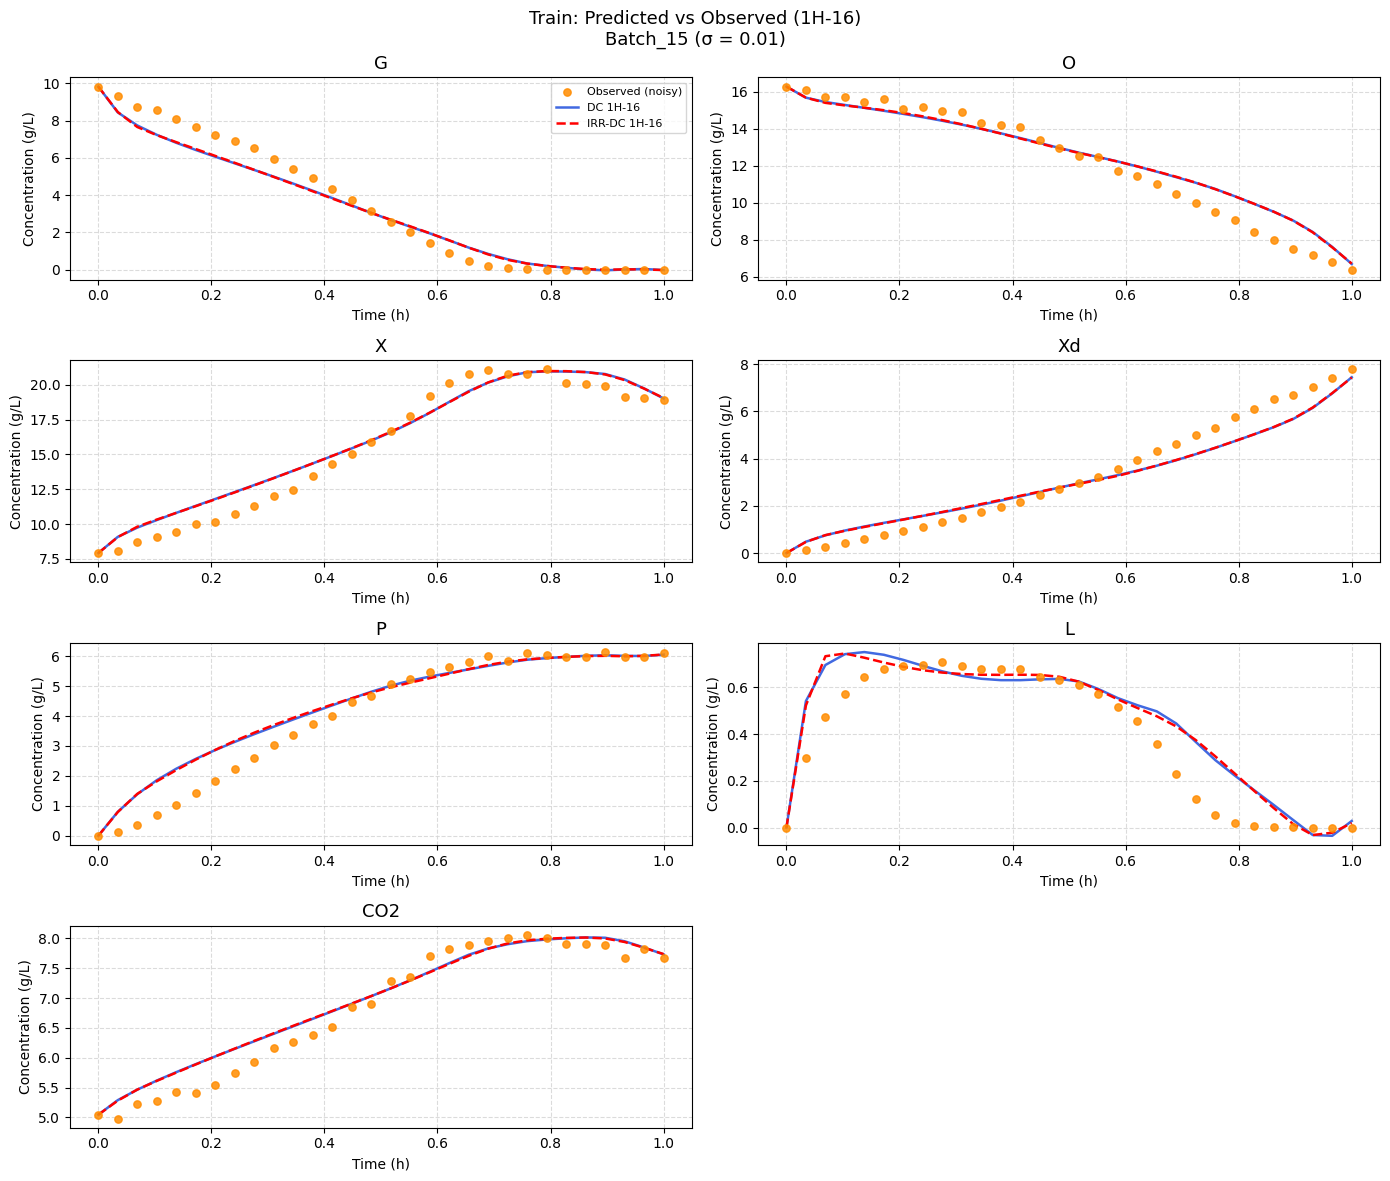

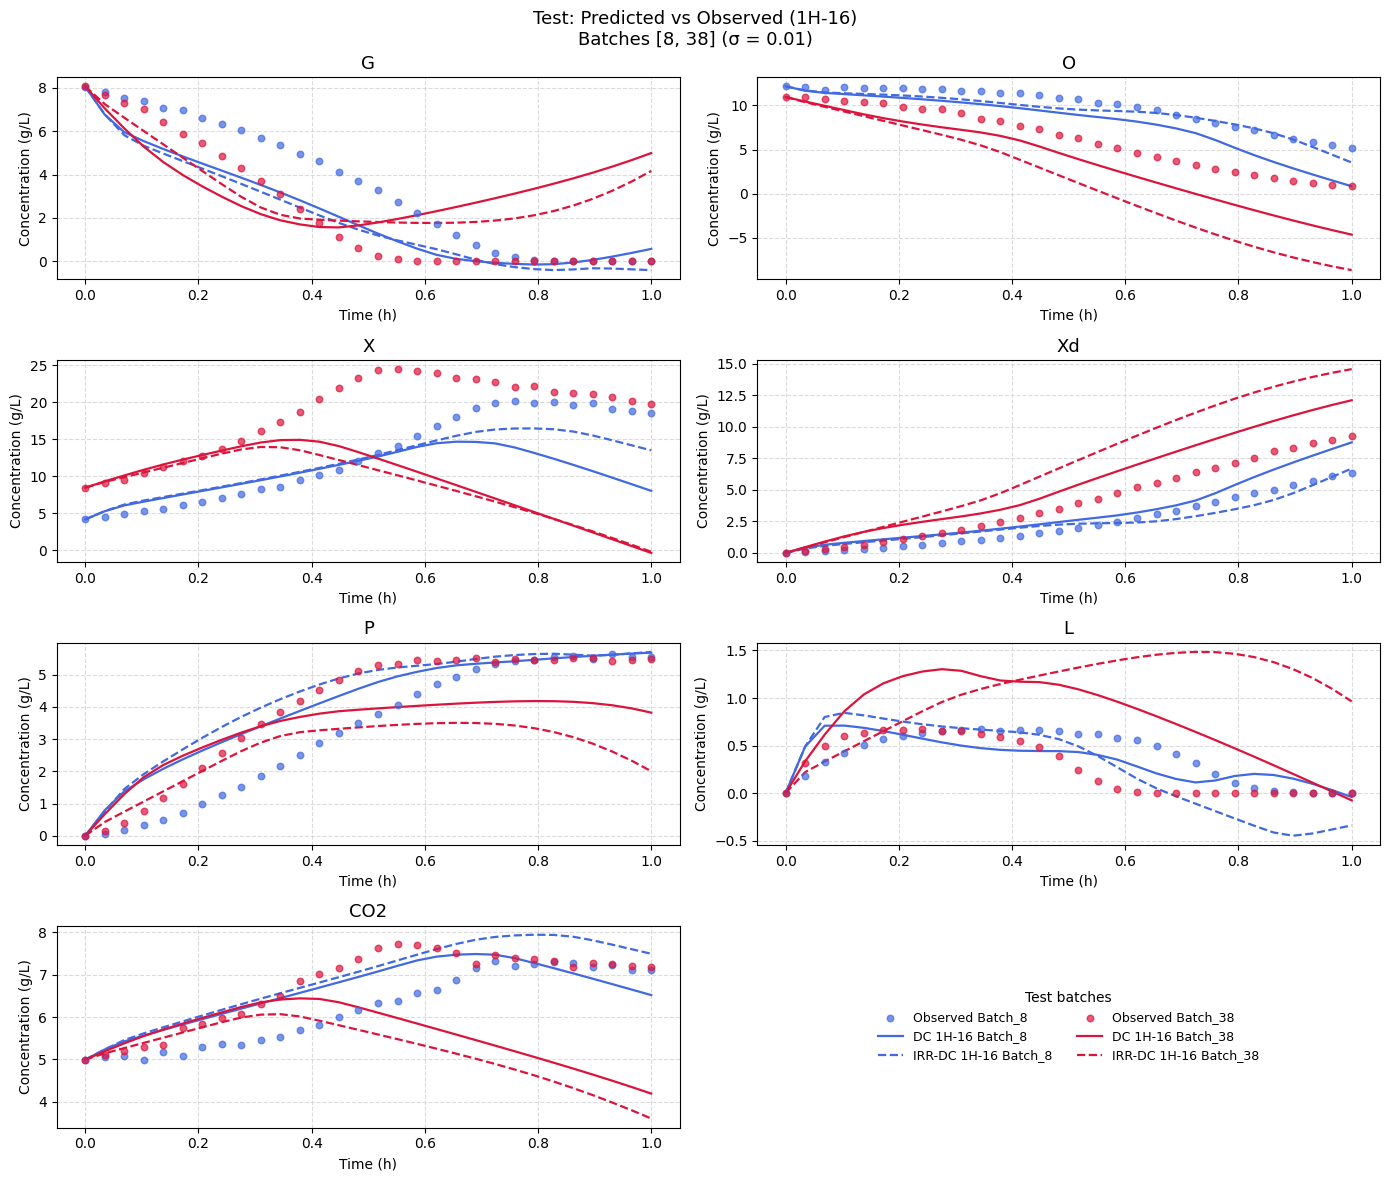

In [13]:
dc_labels = list(predicted_train_dc.keys())
irrdc_labels = list(predicted_train_irrdc.keys())

# Plot only layer sizes that exist in both sweeps.
common_labels = [label for label in dc_labels if label in irrdc_labels]
dc_only_labels = [label for label in dc_labels if label not in irrdc_labels]
print(f"Common layer sizes in DC and IRR-DC sweeps: {common_labels}")
print(f"DC-only layer sizes: {dc_only_labels}")

def plot_train(label, dc_pred, irrdc_pred=None):
    fig, axes = plt.subplots(4, 2, figsize=(14, 12))
    axes = axes.flatten()

    for i, col in enumerate(STATE_COLS):
        ax = axes[i]
        ax.scatter(
            ln_train_grid, ln_Y_obs[:, i],
            color='darkorange', marker='o', s=28, alpha=0.85,
            label='Observed (noisy)', zorder=5
        )
        ax.plot(
            ln_train_grid, dc_pred[:, i],
            color='royalblue', linewidth=1.8, linestyle='-',
            label=f'DC {label}'
        )
        if irrdc_pred is not None:
            ax.plot(
                ln_train_grid, irrdc_pred[:, i],
                color='red', linewidth=1.8, linestyle='--',
                label=f'IRR-DC {label}'
            )

        ax.set_title(col, fontsize=13)
        ax.set_xlabel('Time (h)')
        ax.set_ylabel('Concentration (g/L)')
        ax.grid(True, linestyle='--', color='lightgrey', alpha=0.8)
        if i == 0:
            ax.legend(fontsize=8, loc='best')

    axes[7].set_visible(False)
    plt.suptitle(
        f'Train: Predicted vs Observed ({label})\n'
        f'Batch_{CURRENT_BATCH_ID} (σ = 0.01)',
        fontsize=13
    )
    plt.tight_layout()

def plot_test(label, dc_preds, irrdc_preds=None):
    fig, axes = plt.subplots(4, 2, figsize=(14, 12))
    axes = axes.flatten()
    base_colors = ['royalblue', 'crimson']

    for i, col in enumerate(STATE_COLS):
        ax = axes[i]
        for idx, batch_id in enumerate(TEST_BATCH_IDS):
            c = base_colors[idx % len(base_colors)]
            batch_idx = TEST_BATCH_IDS.index(batch_id)
            obs = Y_test_obs[batch_idx]
            ax.scatter(
                test_grid, obs[:, i],
                color=c, marker='o', s=22, alpha=0.7,
                label=f'Observed Batch_{batch_id}', zorder=5
            )
            ax.plot(
                test_grid, dc_preds[batch_id][:, i],
                color=c, linewidth=1.6, linestyle='-',
                label=f'DC {label} Batch_{batch_id}'
            )
            if irrdc_preds is not None:
                ax.plot(
                    test_grid, irrdc_preds[batch_id][:, i],
                    color=c, linewidth=1.6, linestyle='--',
                    label=f'IRR-DC {label} Batch_{batch_id}'
                )

        ax.set_title(col, fontsize=13)
        ax.set_xlabel('Time (h)')
        ax.set_ylabel('Concentration (g/L)')
        ax.grid(True, linestyle='--', color='lightgrey', alpha=0.8)

    axes[7].axis('off')
    handles, labels = axes[0].get_legend_handles_labels()
    axes[7].legend(
        handles, labels,
        fontsize=9, loc='center', frameon=False, ncol=2,
        title='Test batches'
    )
    plt.suptitle(
        f'Test: Predicted vs Observed ({label})\n'
        f'Batches {TEST_BATCH_IDS} (σ = 0.01)',
        fontsize=13
    )
    plt.tight_layout()

for label in common_labels:
    plot_train(label, predicted_train_dc[label], predicted_train_irrdc[label])
    plot_test(label, predicted_test_dc[label], predicted_test_irrdc[label])

for label in dc_only_labels:
    plot_train(label, predicted_train_dc[label])
    plot_test(label, predicted_test_dc[label])